### Instalasi Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
import warnings
from pathlib import Path
import joblib
import json
from sklearn.base import clone
warnings.filterwarnings("ignore")

## **LOAD DATA DAN PENGECEKAN DATA**

### load data

In [2]:
DATA_PATH = "diabetes.csv"
data = pd.read_csv(DATA_PATH)
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0
...,...,...,...,...,...,...,...,...,...
1995,2,75,64,24,55,29.7,0.370,33,0
1996,8,179,72,42,130,32.7,0.719,36,1
1997,6,85,78,0,0,31.2,0.382,42,0
1998,0,129,110,46,130,67.1,0.319,26,1


In [3]:
# Cek missing values dan nilai 0 d
print("\nNilai 0 pada setiap kolom:")
jumlah_nol = {}
for kolom in data.columns:
    if kolom != 'Outcome':
        hitung_nol = (data[kolom] == 0).sum()
        jumlah_nol[kolom] = hitung_nol
        print(f"{kolom}: {hitung_nol}")

# Total baris yang memiliki minimal satu nilai 0 (selain Outcome dan Pregnancies)
fitur_dengan_nol = data.drop(['Outcome', 'Pregnancies'], axis=1) == 0
total_baris_nol = fitur_dengan_nol.any(axis=1).sum()
persentase_baris_nol = (total_baris_nol / len(data)) * 100
print(f"Total baris yang memiliki minimal satu nilai 0: {total_baris_nol}")
print(f"Persentase baris dengan nilai 0: {persentase_baris_nol:.2f}%")


Nilai 0 pada setiap kolom:
Pregnancies: 301
Glucose: 13
BloodPressure: 90
SkinThickness: 573
Insulin: 956
BMI: 28
DiabetesPedigreeFunction: 0
Age: 0
Total baris yang memiliki minimal satu nilai 0: 965
Persentase baris dengan nilai 0: 48.25%


## **PREPOCESSING**

### Imputasi dengan KNNImputer

In [4]:
kolom_hilang = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
data[kolom_hilang] = data[kolom_hilang].replace(0, np.nan)
if persentase_baris_nol > 10:
    X = data.drop(columns=["Outcome"])
    y = data["Outcome"].to_numpy()
    X_imputed = KNNImputer(n_neighbors=5).fit_transform(X)
    data = pd.DataFrame(X_imputed, columns=X.columns).assign(Outcome=y)
    print(f"Jumlah missing values setelah imputasi:\n{data.isnull().sum()}")
else:
    data = data.dropna(subset=kolom_hilang).reset_index(drop=True)
    print(f"Jumlah data setelah menghapus baris dengan nilai 0: {len(data)}")

Jumlah missing values setelah imputasi:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [5]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2.0,138.0,62.0,35.0,134.8,33.6,0.127,47.0,1
1,0.0,84.0,82.0,31.0,125.0,38.2,0.233,23.0,0
2,0.0,145.0,79.6,38.0,240.8,44.2,0.630,31.0,1
3,0.0,135.0,68.0,42.0,250.0,42.3,0.365,24.0,1
4,1.0,139.0,62.0,41.0,480.0,40.7,0.536,21.0,0
...,...,...,...,...,...,...,...,...,...
1995,2.0,75.0,64.0,24.0,55.0,29.7,0.370,33.0,0
1996,8.0,179.0,72.0,42.0,130.0,32.7,0.719,36.0,1
1997,6.0,85.0,78.0,28.4,79.4,31.2,0.382,42.0,0
1998,0.0,129.0,110.0,46.0,130.0,67.1,0.319,26.0,1


### Normalisasi dengan MinMaxScaler

In [6]:
X = data.drop(columns=["Outcome"])
y = data["Outcome"]
min_max = MinMaxScaler()
X_ternormalisasi = min_max.fit_transform(X)
X_ternormalisasi = pd.DataFrame(X_ternormalisasi, columns=X.columns)
X_ternormalisasi

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.117647,0.606452,0.387755,0.271845,0.165479,0.246795,0.020922,0.433333
1,0.000000,0.258065,0.591837,0.233010,0.152055,0.320513,0.066183,0.033333
2,0.000000,0.651613,0.567347,0.300971,0.310685,0.416667,0.235696,0.166667
3,0.000000,0.587097,0.448980,0.339806,0.323288,0.386218,0.122545,0.050000
4,0.058824,0.612903,0.387755,0.330097,0.638356,0.360577,0.195559,0.000000
...,...,...,...,...,...,...,...,...
1995,0.117647,0.200000,0.408163,0.165049,0.056164,0.184295,0.124680,0.200000
1996,0.470588,0.870968,0.489796,0.339806,0.158904,0.232372,0.273698,0.250000
1997,0.352941,0.264516,0.551020,0.207767,0.089589,0.208333,0.129804,0.350000
1998,0.000000,0.548387,0.877551,0.378641,0.158904,0.783654,0.102904,0.083333


In [7]:
out_dir = Path("for_deployment")
joblib.dump(min_max, out_dir / "min_max_scaler.joblib")

['for_deployment\\min_max_scaler.joblib']

### Split data

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_ternormalisasi, y, test_size=0.3, random_state=42
)
print(f"jumlah data train : {len(X_train)}")
print(f"jumlah data test : {len(X_test)}")

jumlah data train : 1400
jumlah data test : 600


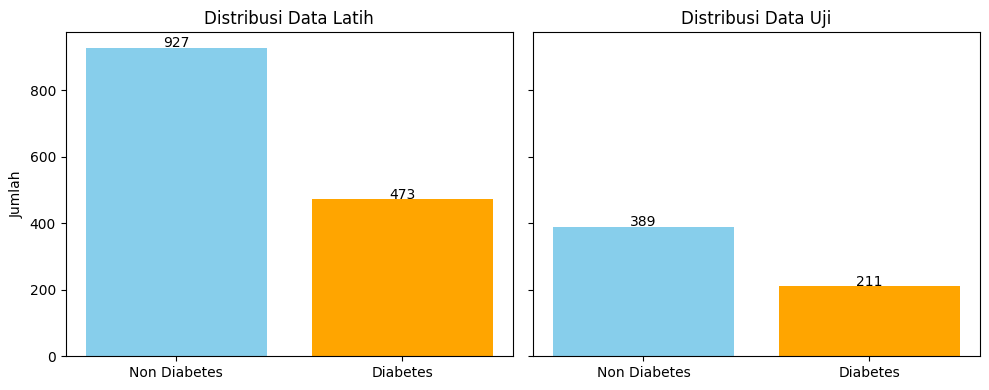

In [9]:
# distribusi kelas pada data latih dan data uji
train_y_counts = y_train.value_counts()
test_y_counts = y_test.value_counts()
test_counts  = y_test.value_counts().reindex([0, 1], fill_value=0)

labels = ["Non Diabetes", "Diabetes"]
x = [0, 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].bar(x, train_y_counts.values, color=["skyblue", "orange"])
axes[0].set_title("Distribusi Data Latih")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Jumlah")

axes[1].bar(x, test_counts.values, color=["skyblue", "orange"])
axes[1].set_title("Distribusi Data Uji")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)

# angka di atas bar (opsional tapi masih sederhana)
for ax, counts in zip(axes, [train_y_counts, test_counts]):
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(int(v)), ha="center")

plt.tight_layout()
plt.show()

### Balancing Data

In [10]:
# balancing dengan SMOTE
jumlah_per_kelas = y_train.value_counts()
jumlah_kelas_mayoritas = jumlah_per_kelas.max()
jumlah_kelas_minoritas = jumlah_per_kelas.min()
IR = jumlah_kelas_mayoritas / jumlah_kelas_minoritas
print(f"Imbalance Ratio: {IR}")

if IR > 1.5:
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
else:
    print("Data sudah cukup seimbang")

Imbalance Ratio: 1.959830866807611


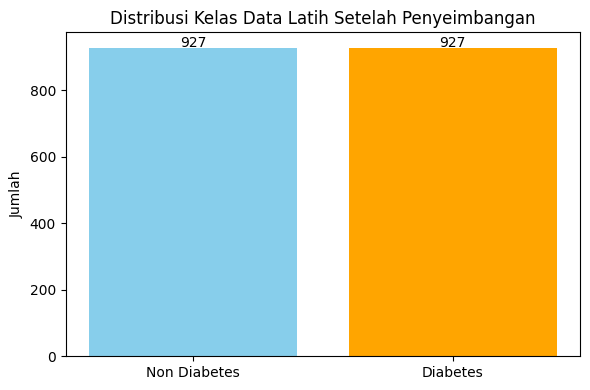

In [11]:
counts_smote =y_train_smote.value_counts()

plt.figure(figsize=(6, 4))
plt.bar([0, 1], counts_smote.values, color=["skyblue", "orange"])
plt.xticks([0, 1], ["Non Diabetes", "Diabetes"])
plt.ylabel("Jumlah")
plt.title("Distribusi Kelas Data Latih Setelah Penyeimbangan")

for i, v in enumerate(counts_smote.values):
    plt.text(i, v + 1, str(int(v)), ha="center")

plt.tight_layout()
plt.show()

## UJI COBA SKENARIO

In [12]:
# Cross-validation dengan KFold
n_splits = 5
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
for split, (train_index, validasi_index) in enumerate(kfold.split(X_train_smote, y_train_smote), 1):
    print(f"split {split}:\n")
    print(f"Jumlah data train: {len(train_index)}")
    print(f"Jumlah data validation: {len(validasi_index)}\n")
    print(f"Train index: {', '.join(map(str, train_index))}")
    print(f"Validation index:  {', '.join(map(str, validasi_index))}\n")

split 1:

Jumlah data train: 1483
Jumlah data validation: 371

Train index: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 45, 46, 47, 48, 50, 52, 53, 54, 55, 56, 57, 58, 60, 61, 62, 64, 66, 68, 72, 74, 75, 77, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 100, 101, 102, 103, 104, 105, 106, 107, 108, 110, 112, 113, 114, 116, 117, 118, 119, 120, 121, 122, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 136, 137, 138, 139, 140, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 164, 165, 166, 167, 169, 170, 171, 172, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 186, 187, 189, 190, 191, 193, 195, 197, 198, 199, 200, 201, 202, 204, 205, 206, 207, 208, 209, 211, 213, 214, 215, 216, 217, 219, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 232, 234, 235, 236, 238, 241, 242, 243, 244, 245, 246, 248, 2

In [85]:
def plot_confusion_matrix(nama_skenario, y_asli, y_prediksi):
    judul = nama_skenario
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_asli, y_prediksi)

    # Menambahkan annot_kws={"size": 16} untuk memperbesar angka di dalam kotak
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Non Diabetes", "Diabetes"],
                yticklabels=["Non Diabetes", "Diabetes"],
                annot_kws={"size": 18}) # <-- Angka 18 bisa kamu naik-turunkan sesuai selera

    # Memperbesar font judul dan label agar seimbang dengan angka di dalam
    ax.set_title(f"Confusion Matrix – {judul}", fontsize=14, pad=10)
    ax.set_xlabel("Prediksi", fontsize=12)
    ax.set_ylabel("Aktual", fontsize=12)

    # Memperbesar font label x dan y (Non Diabetes/Diabetes)
    ax.tick_params(axis='both', labelsize=11)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

def evaluasi_testing(nama_skenario, y_asli, y_prediksi):
    judul = f"{nama_skenario}"
    akurasi = accuracy_score(y_asli, y_prediksi)
    presisi = precision_score(y_asli, y_prediksi, zero_division=0)
    recall  = recall_score(y_asli, y_prediksi, zero_division=0)
    f1      = f1_score(y_asli, y_prediksi, zero_division=0)
    print(f"  Hasil Evaluasi Testing – {judul}")
    print(f"  Akurasi  : {akurasi:.4f}")
    print(f"  Presisi  : {presisi:.4f}")
    print(f"  Recall   : {recall:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    return {
        "Model"   : judul,
        "Akurasi" : round(akurasi, 4),
        "Presisi" : round(presisi, 4),
        "Recall"  : round(recall,  4),
        "F1-Score": round(f1,      4),
    }


def tampilkan_tabel_perbandingan(y_pred, y_asli, nama_skenario="Skenario", jumlah=5):
    """
    Fungsi untuk menampilkan tabel perbandingan hasil prediksi model
    dengan diagnosis asli beserta keterangan klasifikasinya.
    """
    # 1. Pastikan pengambilan data aman (berlaku untuk Pandas Series maupun Numpy Array)
    y_test_sample = y_asli.iloc[:jumlah].values if hasattr(y_asli, 'iloc') else y_asli[:jumlah]
    y_pred_sample = y_pred[:jumlah]

    # 2. Logika Keterangan (TP, TN, FP, FN)
    keterangan = []
    for pred, asli in zip(y_pred_sample, y_test_sample):
        if pred == asli:
            if asli == 1:
                keterangan.append("Tebakan Benar (True Positive)")
            else:
                keterangan.append("Tebakan Benar (True Negative)")
        else:
            if pred == 1 and asli == 0:
                keterangan.append("Tebakan Salah (False Positive)")
            elif pred == 0 and asli == 1:
                keterangan.append("Tebakan Salah (False Negative)")

    # 3. Menyusun DataFrame
    df_perbandingan = pd.DataFrame({
        f'Prediksi {nama_skenario}(y_pred)': y_pred_sample,
        f'Label Aktual(y_test)': y_test_sample,
        'Keterangan': keterangan
    })

    # 4. Menampilkan tabel
    print(f"")
    display(df_perbandingan)

### Skenario 1 (KNN)

In [14]:
import time
_t0 = time.time()
param_grid_knn = {
    "n_neighbors": [5, 7, 9, 11, 13, 15, 17, 19],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(),param_grid_knn, cv=kfold,
    scoring="accuracy",n_jobs=-1,verbose=1,
)
grid_knn.fit(X_train_smote, y_train_smote)
print(f"KNN Best Score: {grid_knn.best_score_:.4f}")
print(f"KNN Best Params: {grid_knn.best_params_}")
results_knn = pd.DataFrame(grid_knn.cv_results_)
best_idx = grid_knn.best_index_
best_idx = grid_knn.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_knn.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_knn.best_score_:.4f}")
waktu_train_knn = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_knn: {waktu_train_knn:.2f} ms")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
KNN Best Score: 0.9439
KNN Best Params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Fold 1: 0.9461
Fold 2: 0.9380
Fold 3: 0.9299
Fold 4: 0.9434
Fold 5: 0.9622
Mean: 0.9439
waktu_train_knn: 6125.40 ms


,Prediksi Skenario 1(y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,1,1,Tebakan Benar (True Positive)
3,1,1,Tebakan Benar (True Positive)
4,1,1,Tebakan Benar (True Positive)


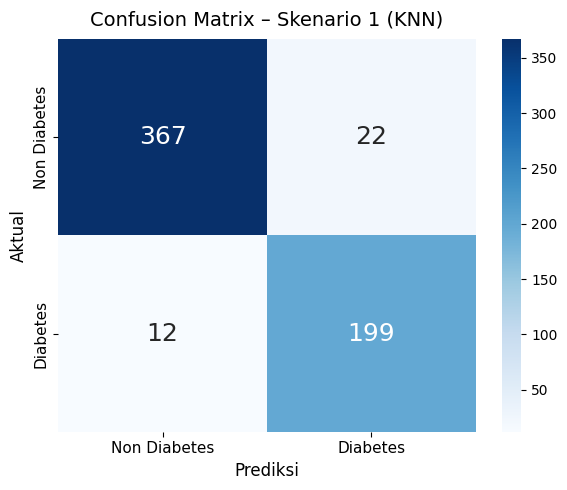

  Hasil Evaluasi Testing – Skenario 1 (KNN)
  Akurasi  : 0.9433
  Presisi  : 0.9005
  Recall   : 0.9431
  F1-Score : 0.9213
waktu_predict_knn: 11.23 ms


In [86]:
knn_final = grid_knn.best_estimator_
import time
_t0 = time.time()
y_pred_knn_final = knn_final.predict(X_test)
waktu_predict_knn = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_knn_final, y_test, nama_skenario="Skenario 1")
plot_confusion_matrix("Skenario 1 (KNN)", y_test, y_pred_knn_final)
hasil_knn_final = evaluasi_testing("Skenario 1 (KNN)", y_test, y_pred_knn_final)
print(f"waktu_predict_knn: {waktu_predict_knn:.2f} ms")

### Skenario 2 (LR)

In [16]:
import time
_t0 = time.time()
# membuat model Logistic Regression dengan GridSearchCV
param_grid_lr = {
    "C": np.logspace(-4, 4, 20),
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l1", "l2"],
}
grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),param_grid_lr,cv=kfold,
    scoring="accuracy",n_jobs=-1,verbose=1,
)
grid_lr.fit(X_train_smote, y_train_smote)
print(f"LR Best Score: {grid_lr.best_score_:.4f}")
print(f"LR Best Params: {grid_lr.best_params_}")
results_lr = pd.DataFrame(grid_lr.cv_results_)
best_idx = grid_lr.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_lr.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_lr.best_score_:.4f}")
waktu_train_lr = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_lr: {waktu_train_lr:.2f} ms")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LR Best Score: 0.7481
LR Best Params: {'C': np.float64(0.012742749857031334), 'penalty': 'l2', 'solver': 'liblinear'}
Fold 1: 0.7601
Fold 2: 0.7089
Fold 3: 0.7466
Fold 4: 0.7655
Fold 5: 0.7595
Mean: 0.7481
waktu_train_lr: 517.00 ms


,Prediksi Skenario 2(y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,1,1,Tebakan Benar (True Positive)
3,1,1,Tebakan Benar (True Positive)
4,1,1,Tebakan Benar (True Positive)


waktu_predict_lr: 1.48 ms


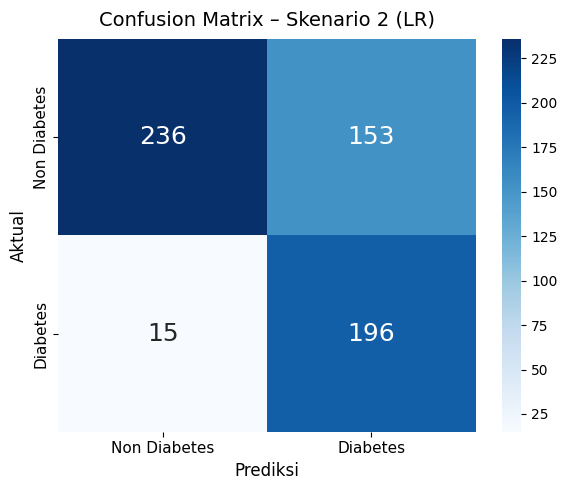

  Hasil Evaluasi Testing – Skenario 2 (LR)
  Akurasi  : 0.7200
  Presisi  : 0.5616
  Recall   : 0.9289
  F1-Score : 0.7000


In [87]:
lr_final = grid_lr.best_estimator_
import time
_t0 = time.time()
y_pred_lr_final = lr_final.predict(X_test)
waktu_predict_lr = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_lr_final, y_test, nama_skenario="Skenario 2")
print(f"waktu_predict_lr: {waktu_predict_lr:.2f} ms")
plot_confusion_matrix("Skenario 2 (LR)", y_test, y_pred_lr_final)
hasil_lr_final = evaluasi_testing("Skenario 2 (LR)", y_test, y_pred_lr_final)

### Skenario 3 (SVM)

In [18]:
import time
_t0 = time.time()
# membuat model SVM dengan GridSearchCV
param_grid_svm = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf", "linear"],
}
grid_svm = GridSearchCV(
    SVC(random_state=42, probability=True),param_grid_svm,cv=kfold,
    scoring="accuracy",n_jobs=-1,verbose=1,
)
grid_svm.fit(X_train_smote, y_train_smote)
print(f"SVM Best Score: {grid_svm.best_score_:.4f}")
print(f"SVM Best Params: {grid_svm.best_params_}")
results_svm = pd.DataFrame(grid_svm.cv_results_)
best_idx = grid_svm.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_svm.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_svm.best_score_:.4f}")
waktu_train_svm = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_svm: {waktu_train_svm:.2f} ms")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Best Score: 0.9186
SVM Best Params: {'C': 1000, 'gamma': 'scale', 'kernel': 'rbf'}
Fold 1: 0.9326
Fold 2: 0.9245
Fold 3: 0.9057
Fold 4: 0.9030
Fold 5: 0.9270
Mean: 0.9186
waktu_train_svm: 10894.63 ms


,Prediksi Skenario 3(y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,1,1,Tebakan Benar (True Positive)
3,1,1,Tebakan Benar (True Positive)
4,1,1,Tebakan Benar (True Positive)


waktu_predict_svm: 26.68 ms


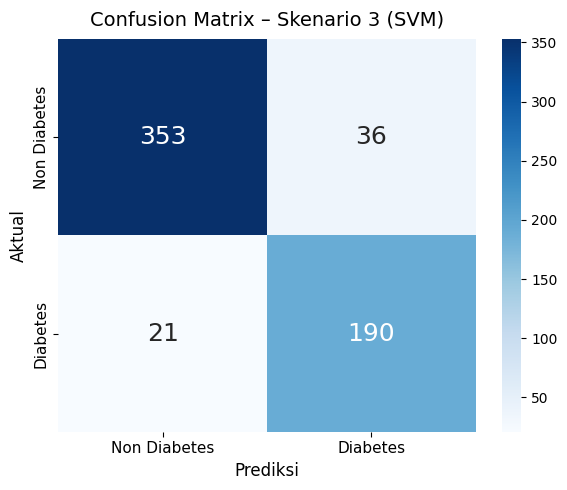

  Hasil Evaluasi Testing – Skenario 3 (SVM)
  Akurasi  : 0.9050
  Presisi  : 0.8407
  Recall   : 0.9005
  F1-Score : 0.8696


In [88]:
svm_final = grid_svm.best_estimator_
import time
_t0 = time.time()
y_pred_svm_final = svm_final.predict(X_test)
waktu_predict_svm = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_svm_final, y_test, nama_skenario="Skenario 3")
print(f"waktu_predict_svm: {waktu_predict_svm:.2f} ms")
plot_confusion_matrix("Skenario 3 (SVM)", y_test, y_pred_svm_final)
hasil_svm_final = evaluasi_testing("Skenario 3 (SVM)", y_test, y_pred_svm_final)

### Skenario 4 (ANN)

In [20]:
import time
_t0 = time.time()
# membuat model ann dengan GridSearchCV
param_grid_ann = {
    "max_iter": [100, 500, 1000],
    "hidden_layer_sizes": [(100,), (50, 50), (30, 20), (20, 10)],
    "activation": ["relu", "tanh", "logistic"],
    "learning_rate_init": [0.0001, 0.001],
}
grid_ann = GridSearchCV(
    MLPClassifier(random_state=42),param_grid_ann,cv=kfold,
    scoring="accuracy",n_jobs=-1,verbose=1,
)
grid_ann.fit(X_train_smote, y_train_smote)
print(f"ANN Best Score: {grid_ann.best_score_:.4f}")
print(f"ANN Best Params: {grid_ann.best_params_}")
results_ann = pd.DataFrame(grid_ann.cv_results_)
best_idx = grid_ann.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_ann.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_ann.best_score_:.4f}")
waktu_train_ann = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_ann: {waktu_train_ann:.2f} ms")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
ANN Best Score: 0.8247
ANN Best Params: {'activation': 'relu', 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.001, 'max_iter': 500}
Fold 1: 0.8032
Fold 2: 0.8086
Fold 3: 0.8464
Fold 4: 0.8329
Fold 5: 0.8324
Mean: 0.8247
waktu_train_ann: 109540.86 ms


,Prediksi Skenario 4(y_pred),Label Aktual(y_test),Keterangan
0,0,1,Tebakan Salah (False Negative)
1,0,0,Tebakan Benar (True Negative)
2,1,1,Tebakan Benar (True Positive)
3,1,1,Tebakan Benar (True Positive)
4,1,1,Tebakan Benar (True Positive)


waktu_predict_ann: 2.34 ms


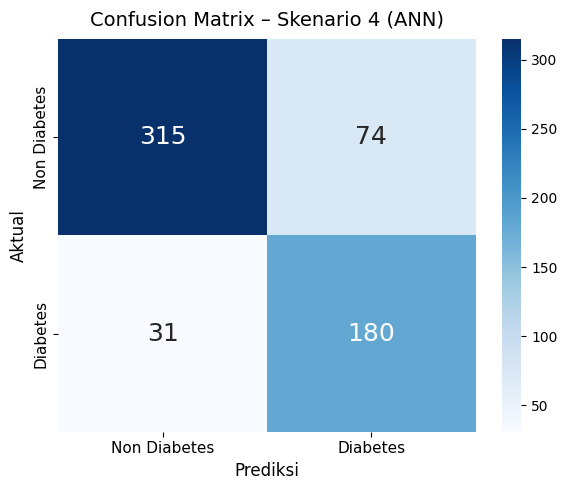

  Hasil Evaluasi Testing – Skenario 4 (ANN)
  Akurasi  : 0.8250
  Presisi  : 0.7087
  Recall   : 0.8531
  F1-Score : 0.7742


In [89]:
ann_final = grid_ann.best_estimator_
import time
_t0 = time.time()
y_pred_ann_final = ann_final.predict(X_test)
waktu_predict_ann = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_ann_final, y_test, nama_skenario="Skenario 4")
print(f"waktu_predict_ann: {waktu_predict_ann:.2f} ms")
plot_confusion_matrix("Skenario 4 (ANN)", y_test, y_pred_ann_final)
hasil_ann_final = evaluasi_testing("Skenario 4 (ANN)", y_test, y_pred_ann_final)

### MEMBUAT DATA TRAINING DAN TESTING UNTUK META LEARNER

In [22]:
import time
_t0_meta_train = time.time()
models = [
    ("knn", knn_final),("lr",  lr_final),
    ("svm", svm_final),("ann", ann_final),
]
dataset_training_meta = []
for train_idx, val_idx in kfold.split(X_train_smote, y_train_smote):
    X_tr  = X_train_smote.iloc[train_idx]
    y_tr  = y_train_smote.iloc[train_idx]
    X_val = X_train_smote.iloc[val_idx]
    fold_preds = []
    for name, est in models:
        model = clone(est)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_val)
        fold_preds.append(pd.DataFrame(
            proba,index=val_idx,columns=[f"{name}_prob_0", f"{name}_prob_1"]
        ))
    fold_df = pd.concat(fold_preds, axis=1)
    dataset_training_meta.append(fold_df)
df_fitur_meta = pd.concat(dataset_training_meta).sort_index()
waktu_buat_dataset_training_meta = (time.time() - _t0_meta_train) * 1000  # ms
print(f"waktu_buat_dataset_training_meta: {waktu_buat_dataset_training_meta:.2f} ms")

waktu_buat_dataset_training_meta: 27166.96 ms


In [23]:
df_fitur_meta.to_excel("fitur_meta_training.xlsx", index=False)
df_fitur_meta

,knn_prob_0,knn_prob_1,lr_prob_0,lr_prob_1,svm_prob_0,svm_prob_1,ann_prob_0,ann_prob_1
0,0.000000,1.000000,0.485175,0.514825,0.260130,0.739870,0.333735,0.666265
1,1.000000,0.000000,0.504863,0.495137,0.680113,0.319887,0.865113,0.134887
2,1.000000,0.000000,0.447943,0.552057,0.992605,0.007395,0.991202,0.008798
3,0.000000,1.000000,0.498009,0.501991,0.260242,0.739758,0.968645,0.031355
4,0.603858,0.396142,0.520744,0.479256,0.569228,0.430772,0.577136,0.422864
...,...,...,...,...,...,...,...,...
1849,0.000000,1.000000,0.424088,0.575912,0.251996,0.748004,0.065535,0.934465
1850,0.000000,1.000000,0.478812,0.521188,0.267627,0.732373,0.162687,0.837313
1851,0.176928,0.823072,0.488084,0.511916,0.333799,0.666201,0.192172,0.807828
1852,0.000000,1.000000,0.435854,0.564146,0.225706,0.774294,0.250542,0.749458


In [24]:
import time
_t0_meta_test = time.time()
dataset_testing_meta = []
for name, est in models:
    proba = est.predict_proba(X_test)
    dataset_testing_meta.append(pd.DataFrame(
        proba,
        columns=[f"{name}_prob_0", f"{name}_prob_1"]
    ))
df_fitur_meta_uji = pd.concat(dataset_testing_meta, axis=1)
waktu_buat_dataset_testing_meta = (time.time() - _t0_meta_test) * 1000  # ms
print(f"waktu_buat_dataset_testing_meta: {waktu_buat_dataset_testing_meta:.2f} ms")

waktu_buat_dataset_testing_meta: 43.87 ms


In [25]:
df_fitur_meta_uji.to_excel("fitur_meta_testing.xlsx", index=False)
df_fitur_meta_uji

,knn_prob_0,knn_prob_1,lr_prob_0,lr_prob_1,svm_prob_0,svm_prob_1,ann_prob_0,ann_prob_1
0,0.000000,1.000000,0.442935,0.557065,1.933470e-01,0.806653,0.791554,0.208446
1,1.000000,0.000000,0.559073,0.440927,9.914544e-01,0.008546,0.999481,0.000519
2,0.000000,1.000000,0.400965,0.599035,9.880061e-02,0.901199,0.246991,0.753009
3,0.000000,1.000000,0.478873,0.521127,1.934734e-01,0.806527,0.403671,0.596329
4,0.000000,1.000000,0.458529,0.541471,1.128881e-13,1.000000,0.083273,0.916727
...,...,...,...,...,...,...,...,...
595,1.000000,0.000000,0.411996,0.588004,7.757856e-01,0.224214,0.578346,0.421654
596,1.000000,0.000000,0.382424,0.617576,7.759494e-01,0.224051,0.682585,0.317415
597,0.384457,0.615543,0.497534,0.502466,5.988249e-01,0.401175,0.335647,0.664353
598,0.000000,1.000000,0.380869,0.619131,1.933088e-01,0.806691,0.075447,0.924553


In [26]:
X_meta_latih = df_fitur_meta
y_meta_latih = y_train_smote
X_meta_uji = df_fitur_meta_uji
y_meta_uji = y_test

In [27]:
print((df_fitur_meta.index == y_train_smote.index).all()) ## ngecek apakah urutan index fitur meta latih sama dengan label latih

True


### Skenario 5 Stacking (Meta-KNN)

In [28]:
import time
_t0 = time.time()
# membuat model KNN Meta dengan GridSearchCV
grid_knn_meta = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_knn_meta.fit(X_meta_latih, y_meta_latih)
print(f"KNN Meta Best Score: {grid_knn_meta.best_score_:.4f}")
print(f"KNN Meta Best Params: {grid_knn_meta.best_params_}")
results_knn_meta = pd.DataFrame(grid_knn_meta.cv_results_)
best_idx = grid_knn_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_knn_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_knn_meta.best_score_:.4f}")
waktu_train_knn_meta = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_knn_meta: {waktu_train_knn_meta:.2f} ms")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
KNN Meta Best Score: 0.9466
KNN Meta Best Params: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Fold 1: 0.9488
Fold 2: 0.9488
Fold 3: 0.9326
Fold 4: 0.9407
Fold 5: 0.9622
Mean: 0.9466
waktu_train_knn_meta: 424.56 ms


,Prediksi Skenario 5 Stacking (Meta-KNN)(y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,1,1,Tebakan Benar (True Positive)
3,1,1,Tebakan Benar (True Positive)
4,1,1,Tebakan Benar (True Positive)


waktu_predict_knn_meta: 24.48 ms


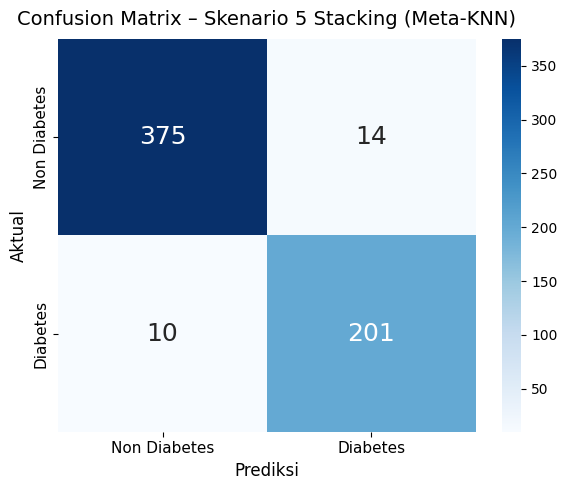

  Hasil Evaluasi Testing – Skenario 5 Stacking (Meta-KNN)
  Akurasi  : 0.9600
  Presisi  : 0.9349
  Recall   : 0.9526
  F1-Score : 0.9437


In [90]:
knn_meta_final = grid_knn_meta.best_estimator_
import time
_t0 = time.time()
y_pred_knn_meta_final = knn_meta_final.predict(X_meta_uji)
waktu_predict_knn_meta = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_knn_meta_final, y_test, nama_skenario="Skenario 5 Stacking (Meta-KNN)")
print(f"waktu_predict_knn_meta: {waktu_predict_knn_meta:.2f} ms")
plot_confusion_matrix("Skenario 5 Stacking (Meta-KNN)", y_test, y_pred_knn_meta_final)
hasil_knn_meta_final = evaluasi_testing("Skenario 5 Stacking (Meta-KNN)", y_test, y_pred_knn_meta_final)

### Skenario 6 Stacking (Meta-LR)

In [30]:
import time
_t0 = time.time()
# membuat model Logistic Regression Meta dengan GridSearchCV
grid_logreg_meta = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_logreg_meta.fit(X_meta_latih, y_meta_latih)
print(f"LogReg Meta Best Score: {grid_logreg_meta.best_score_:.4f}")
print(f"LogReg Meta Best Params: {grid_logreg_meta.best_params_}")
results_logreg_meta = pd.DataFrame(grid_logreg_meta.cv_results_)
best_idx = grid_logreg_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_logreg_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_logreg_meta.best_score_:.4f}")
waktu_train_lr_meta = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_lr_meta: {waktu_train_lr_meta:.2f} ms")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LogReg Meta Best Score: 0.9444
LogReg Meta Best Params: {'C': np.float64(0.08858667904100823), 'penalty': 'l2', 'solver': 'liblinear'}
Fold 1: 0.9488
Fold 2: 0.9461
Fold 3: 0.9407
Fold 4: 0.9326
Fold 5: 0.9541
Mean: 0.9444
waktu_train_lr_meta: 608.24 ms


,Prediksi Skenario 6 Stacking (Meta-lr)(y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,1,1,Tebakan Benar (True Positive)
3,1,1,Tebakan Benar (True Positive)
4,1,1,Tebakan Benar (True Positive)


waktu_predict_lr_meta: 15.88 ms


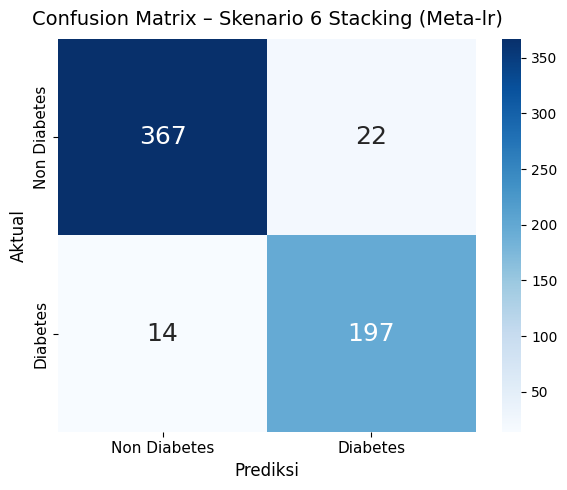

  Hasil Evaluasi Testing – Skenario 6 Stacking (Meta-lr)
  Akurasi  : 0.9400
  Presisi  : 0.8995
  Recall   : 0.9336
  F1-Score : 0.9163


In [91]:
logreg_meta_final = grid_logreg_meta.best_estimator_
import time
_t0 = time.time()
y_pred_lr_meta_final = logreg_meta_final.predict(X_meta_uji)
waktu_predict_lr_meta = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_lr_meta_final, y_test, nama_skenario="Skenario 6 Stacking (Meta-lr)")
print(f"waktu_predict_lr_meta: {waktu_predict_lr_meta:.2f} ms")
plot_confusion_matrix("Skenario 6 Stacking (Meta-lr)", y_test, y_pred_lr_meta_final)
hasil_lr_meta_final = evaluasi_testing("Skenario 6 Stacking (Meta-lr)", y_test, y_pred_lr_meta_final)

### Skenario 7 Stacking (Meta-SVM)

In [32]:
import time
_t0 = time.time()
# membuat model Support Vector Machine Meta dengan GridSearchCV
grid_svm_meta = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid_svm,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_svm_meta.fit(X_meta_latih, y_meta_latih)
print(f"SVM Meta Best Score: {grid_svm_meta.best_score_:.4f}")
print(f"SVM Meta Best Params: {grid_svm_meta.best_params_}")
results_svm_meta = pd.DataFrame(grid_svm_meta.cv_results_)
best_idx = grid_svm_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_svm_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_svm_meta.best_score_:.4f}")
waktu_train_svm_meta = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_svm_meta: {waktu_train_svm_meta:.2f} ms")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Meta Best Score: 0.9439
SVM Meta Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Fold 1: 0.9461
Fold 2: 0.9407
Fold 3: 0.9326
Fold 4: 0.9407
Fold 5: 0.9595
Mean: 0.9439
waktu_train_svm_meta: 4514.01 ms


,Prediksi Skenario 7 Stacking (Meta-SVM)(y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,1,1,Tebakan Benar (True Positive)
3,1,1,Tebakan Benar (True Positive)
4,1,1,Tebakan Benar (True Positive)


waktu_predict_svm_meta: 5.23 ms


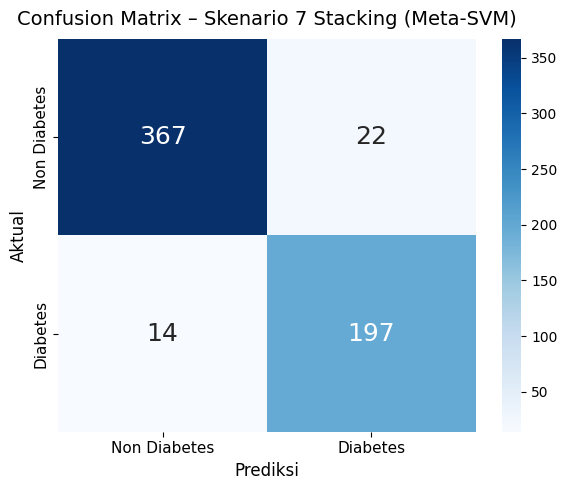

  Hasil Evaluasi Testing – Skenario 7 Stacking (Meta-SVM)
  Akurasi  : 0.9400
  Presisi  : 0.8995
  Recall   : 0.9336
  F1-Score : 0.9163


In [92]:
svm_meta_final = grid_svm_meta.best_estimator_
import time
_t0 = time.time()
y_pred_svm_meta_final = svm_meta_final.predict(X_meta_uji)
waktu_predict_svm_meta = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_svm_meta_final, y_test, nama_skenario="Skenario 7 Stacking (Meta-SVM)")
print(f"waktu_predict_svm_meta: {waktu_predict_svm_meta:.2f} ms")
plot_confusion_matrix("Skenario 7 Stacking (Meta-SVM)", y_test, y_pred_svm_meta_final)
hasil_svm_meta_final = evaluasi_testing("Skenario 7 Stacking (Meta-SVM)", y_test, y_pred_svm_meta_final)

### Skenario 8 Stacking (Meta-ANN)

In [34]:
import time
_t0 = time.time()
# membuat model ANN Meta dengan GridSearchCV
grid_ann_meta = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid_ann,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_ann_meta.fit(X_meta_latih, y_meta_latih)
print(f"ANN Meta Best Score: {grid_ann_meta.best_score_:.4f}")
print(f"ANN Meta Best Params: {grid_ann_meta.best_params_}")
results_ann_meta = pd.DataFrame(grid_ann_meta.cv_results_)
best_idx = grid_ann_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_ann_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_ann_meta.best_score_:.4f}")
waktu_train_ann_meta = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_ann_meta: {waktu_train_ann_meta:.2f} ms")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
ANN Meta Best Score: 0.9455
ANN Meta Best Params: {'activation': 'logistic', 'hidden_layer_sizes': (20, 10), 'learning_rate_init': 0.001, 'max_iter': 500}
Fold 1: 0.9515
Fold 2: 0.9434
Fold 3: 0.9407
Fold 4: 0.9272
Fold 5: 0.9649
Mean: 0.9455
waktu_train_ann_meta: 66359.46 ms


,Prediksi Skenario 8 Stacking (Meta-ANN)(y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,1,1,Tebakan Benar (True Positive)
3,1,1,Tebakan Benar (True Positive)
4,1,1,Tebakan Benar (True Positive)


waktu_predict_ann_meta: 75.07 ms


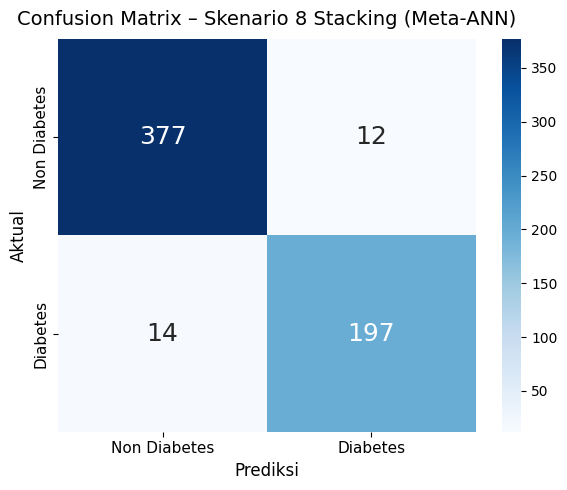

  Hasil Evaluasi Testing – Skenario 8 Stacking (Meta-ANN)
  Akurasi  : 0.9567
  Presisi  : 0.9426
  Recall   : 0.9336
  F1-Score : 0.9381


In [100]:
ann_meta_final = grid_ann_meta.best_estimator_
import time
_t0 = time.time()
y_pred_ann_meta_final = ann_meta_final.predict(X_meta_uji)
waktu_predict_ann_meta = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_ann_meta_final, y_test, nama_skenario="Skenario 8 Stacking (Meta-ANN)")
print(f"waktu_predict_ann_meta: {waktu_predict_ann_meta:.2f} ms")
plot_confusion_matrix("Skenario 8 Stacking (Meta-ANN)", y_test, y_pred_ann_meta_final)
hasil_ann_meta_final = evaluasi_testing("Skenario 8 Stacking (Meta-ANN)", y_test, y_pred_ann_meta_final)

In [36]:
hasil_semua = [
    hasil_knn_final,
    hasil_lr_final,
    hasil_svm_final,
    hasil_ann_final,
    hasil_knn_meta_final,
    hasil_lr_meta_final,
    hasil_svm_meta_final,
    hasil_ann_meta_final,
]

df_perbandingan = pd.DataFrame(hasil_semua)
df_perbandingan.index = range(1, len(df_perbandingan) + 1)
df_perbandingan.index.name = "No"
display(df_perbandingan)
print("\nModel Terbaik per Metrik:")
for metrik in ["Akurasi", "Presisi", "Recall", "F1-Score"]:
    best_idx = df_perbandingan[metrik].idxmax()
    best_model = df_perbandingan.loc[best_idx, "Model"]
    best_val   = df_perbandingan.loc[best_idx, metrik]
    print(f"  {metrik:10s}: {best_model} ({best_val:.4f})")

,Model,Akurasi,Presisi,Recall,F1-Score
No,,,,,
1,Skenario 1 (KNN),0.9433,0.9005,0.9431,0.9213
2,Skenario 2 (LR),0.7200,0.5616,0.9289,0.7000
3,Skenario 3 (SVM),0.9050,0.8407,0.9005,0.8696
4,Skenario 4 (ANN),0.8250,0.7087,0.8531,0.7742
5,Skenario 5 Stacking (Meta-KNN),0.9600,0.9349,0.9526,0.9437
6,Skenario 6 Stacking (Meta-lr),0.9400,0.8995,0.9336,0.9163
7,Skenario 7 Stacking (Meta-SVM),0.9400,0.8995,0.9336,0.9163
8,Skenario 8 Stacking (Meta-ANN),0.9567,0.9426,0.9336,0.9381



Model Terbaik per Metrik:
  Akurasi   : Skenario 5 Stacking (Meta-KNN) (0.9600)
  Presisi   : Skenario 8 Stacking (Meta-ANN) (0.9426)
  Recall    : Skenario 5 Stacking (Meta-KNN) (0.9526)
  F1-Score  : Skenario 5 Stacking (Meta-KNN) (0.9437)


# EXPORT HASIL KOMBINASI PARAMETER

In [37]:
import pandas as pd

def cv_results_to_export(nama_model, results_df):
    df = results_df[["params", "mean_test_score", "rank_test_score"]].copy()
    df = df.dropna(subset=["mean_test_score"])

    df.rename(columns={
        "params": "Kombinasi Parameter",
        "mean_test_score": "Rata Rata",
        "rank_test_score": "Peringkat",
    }, inplace=True)

    df.insert(0, "Nama Model", nama_model)
    df["Kombinasi Parameter"] = df["Kombinasi Parameter"].astype(str)
    return df

# =========================
# BASE (sheet 1)
# =========================
df_base = pd.concat([
    cv_results_to_export("KNN", results_knn),
    cv_results_to_export("LogReg", results_lr),
    cv_results_to_export("SVM", results_svm),
    cv_results_to_export("ANN", results_ann),
], ignore_index=True)

df_base = df_base.sort_values(["Nama Model", "Peringkat"], ascending=[True, True]).reset_index(drop=True)
df_base.insert(0, "No", range(1, len(df_base) + 1))

# =========================
# META (sheet 2)
# =========================
df_meta = pd.concat([
    cv_results_to_export("KNN", results_knn_meta),
    cv_results_to_export("LogReg", results_logreg_meta),
    cv_results_to_export("SVM", results_svm_meta),
    cv_results_to_export("ANN", results_ann_meta),
], ignore_index=True)

df_meta = df_meta.sort_values(["Nama Model", "Peringkat"], ascending=[True, True]).reset_index(drop=True)
df_meta.insert(0, "No", range(1, len(df_meta) + 1))

# =========================
# EXPORT (2 sheet)
# =========================
output_excel = "rekap_kombinasi_parameter_base_dan_meta.xlsx"
with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    df_base.to_excel(writer, index=False, sheet_name="Base")
    df_meta.to_excel(writer, index=False, sheet_name="Meta")

print("Berhasil membuat:", output_excel)
print("Total baris Base:", len(df_base))
print("Total baris Meta:", len(df_meta))

Berhasil membuat: rekap_kombinasi_parameter_base_dan_meta.xlsx
Total baris Base: 200
Total baris Meta: 200


# OUTPUT PELATIHAN MODEL

### KNN

In [38]:
print(f"Metrik Jarak: {knn_final.effective_metric_}")
print(f"Jumlah Sampel Latihan: {knn_final.n_samples_fit_}")

Metrik Jarak: manhattan
Jumlah Sampel Latihan: 1854


## LR

In [39]:
print(f"Koefisien (Bobot): \n{lr_final.coef_}")
print(f"Intercept (Bias): {lr_final.intercept_}")
print(f"Jumlah Iterasi: {lr_final.n_iter_}")

Koefisien (Bobot): 
[[ 0.27976254  0.64898804 -0.02699145  0.12672871  0.24276224  0.21146158
   0.08651063  0.3207088 ]]
Intercept (Bias): [-0.51686684]
Jumlah Iterasi: [4]


## SVM

In [ ]:
print(f"Indeks Support Vectors: {svm_final.support_}")
print(f"Jumlah Support Vectors per kelas: {svm_final.n_support_[0]} (kelas 0), {svm_final.n_support_[1]} (kelas 1)")
print(f"Konstanta Bias (intercept_): {svm_final.intercept_}")
print(f"Total Support Vectors: {sum(svm_final.n_support_)}")

Indeks Support Vectors: [  16   18   25   36   68   78   87   88  114  125  131  135  150  151
  161  176  188  195  197  203  209  212  217  224  225  237  252  253
  276  296  304  309  313  315  333  337  344  350  353  359  367  369
  372  375  377  383  388  406  412  413  419  425  428  430  443  448
  449  452  461  469  477  478  480  482  487  493  507  516  520  548
  550  557  561  565  567  575  578  579  580  594  596  605  606  607
  608  612  618  634  646  647  653  654  655  662  672  676  679  681
  682  684  692  695  706  708  722  723  727  730  733  736  737  752
  757  760  765  769  773  774  780  782  799  804  808  816  827  828
  829  836  837  840  845  858  861  871  877  878  890  892  898  901
  906  912  915  916  919  924  929  931  936  940  942  945  946  953
  955  956  959  960  962  975  977 1001 1002 1003 1007 1009 1014 1020
 1027 1028 1031 1033 1038 1046 1057 1060 1065 1066 1068 1069 1071 1073
 1082 1087 1090 1097 1101 1104 1107 1111 1113 1118 11

## ANN

In [41]:
# Hasil pelatihan ANN
print(ann_final.loss_)
print(ann_final.n_iter_)
print(ann_final.t_)
print(ann_final.n_layers_)
print(ann_final.n_outputs_)
print(ann_final.out_activation_)
print(f"\nShape Matriks Bobot (coefs_): {[c.shape for c in ann_final.coefs_]}")
print(f"Shape Vektor Bias (intercepts_): {[i.shape for i in ann_final.intercepts_]}")

0.31374944926761905
500
927000
4
1
logistic

Shape Matriks Bobot (coefs_): [(8, 50), (50, 50), (50, 1)]
Shape Vektor Bias (intercepts_): [(50,), (50,), (1,)]


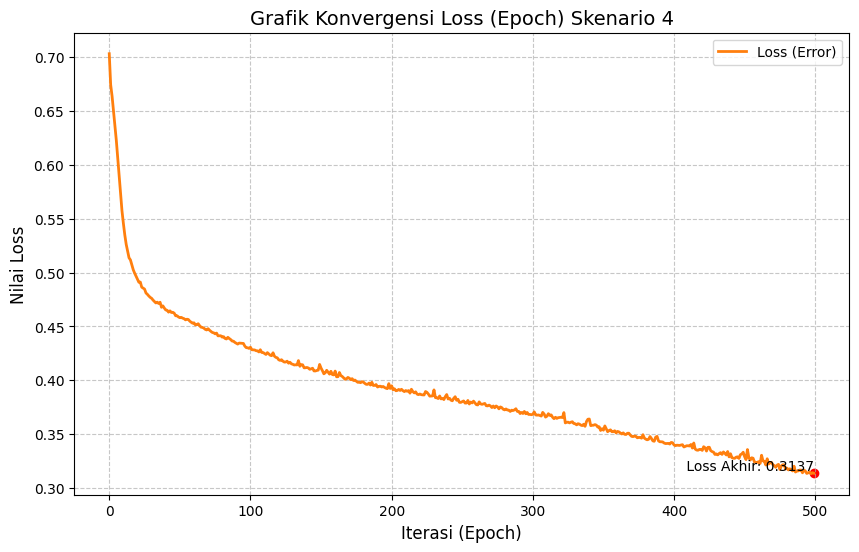

In [42]:
import matplotlib.pyplot as plt

# 1. Mengambil data loss_curve_ dari model yang sudah dilatih
loss_values = ann_final.loss_curve_

# 2. Membuat plot
plt.figure(figsize=(10, 6))
plt.plot(loss_values, label='Loss (Error)', color='tab:orange', linewidth=2)

# 3. Menambahkan label dan judul untuk kebutuhan Skripsi
plt.title('Grafik Konvergensi Loss (Epoch) Skenario 4', fontsize=14)
plt.xlabel('Iterasi (Epoch)', fontsize=12)
plt.ylabel('Nilai Loss', fontsize=12)

# 4. Menandai titik akhir (konvergensi)
plt.scatter(len(loss_values)-1, loss_values[-1], color='red')
plt.text(len(loss_values)-1, loss_values[-1], f' Loss Akhir: {loss_values[-1]:.4f}',
         verticalalignment='bottom', horizontalalignment='right')

# 5. Mempercantik tampilan
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## KNN-META

In [43]:
print(f"Metrik Jarak: {knn_meta_final.effective_metric_}")
print(f"Jumlah Sampel Latihan: {knn_meta_final.n_samples_fit_}")

Metrik Jarak: manhattan
Jumlah Sampel Latihan: 1854


## LR-META

In [44]:
print(f"Koefisien (Bobot): \n{logreg_meta_final.coef_}")
print(f"Intercept (Bias): {logreg_meta_final.intercept_}")
print(f"Jumlah Iterasi: {logreg_meta_final.n_iter_}")

Koefisien (Bobot): 
[[-2.14567943  2.00872154 -0.1030707  -0.03388718 -0.98755171  0.85059382
  -0.66087889  0.523921  ]]
Intercept (Bias): [-0.13695789]
Jumlah Iterasi: [6]


## SVM-META

In [98]:
print(f"Indeks Support Vectors: {svm_meta_final.support_}")
print(f"Jumlah Support Vectors per kelas: {svm_meta_final.n_support_}")
print(f"Konstanta Bias (intercept_): {svm_meta_final.intercept_}")

Indeks Support Vectors: [   4    8   16   18   36   39   41   58   78   87   88  120  125  127
  140  150  161  163  212  221  223  228  251  252  270  273  294  300
  304  313  316  318  331  333  343  344  350  353  363  371  372  375
  380  383  406  418  419  425  428  437  449  459  461  468  477  493
  561  575  578  598  603  608  626  634  664  672  676  679  681  682
  692  695  708  719  733  760  765  769  773  782  816  820  828  829
  890  915  924  948  955  963 1009 1038 1046 1055 1057 1069 1078 1090
 1097 1115 1119 1132 1158 1172 1178 1187 1189 1203 1205 1206 1216 1217
 1220 1231 1234 1248 1249 1263 1268 1274 1286 1297 1298 1311 1324 1328
 1331 1344 1346 1353 1393 1399   13   26   34   44   51   66   85   96
  128  144  145  149  155  177  194  231  280  303  336  394  407  410
  417  420  442  465  501  514  562  577  616  624  629  637  687  748
  758  761  786  850  857  875  961  966  969  979 1008 1012 1022 1024
 1025 1041 1102 1106 1130 1162 1166 1191 1229 1251 12

## ANN-META

In [46]:
# Hasil pelatihan ANN
print(ann_meta_final.loss_)
print(ann_meta_final.n_iter_)
print(ann_meta_final.t_)
print(ann_meta_final.n_layers_)
print(ann_meta_final.n_outputs_)
print(ann_meta_final.out_activation_)
print(f"\nShape Matriks Bobot (coefs_): {[c.shape for c in ann_meta_final.coefs_]}")
print(f"Shape Vektor Bias (intercepts_): {[i.shape for i in ann_meta_final.intercepts_]}")

0.16957740782478342
162
300348
4
1
logistic

Shape Matriks Bobot (coefs_): [(8, 20), (20, 10), (10, 1)]
Shape Vektor Bias (intercepts_): [(20,), (10,), (1,)]


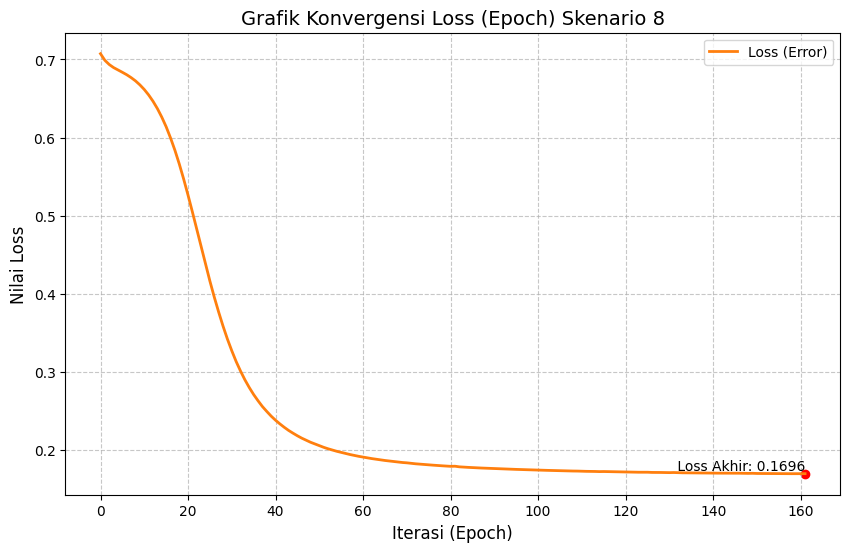

In [47]:
import matplotlib.pyplot as plt

# 1. Mengambil data loss_curve_ dari model yang sudah dilatih
loss_values = ann_meta_final.loss_curve_

# 2. Membuat plot
plt.figure(figsize=(10, 6))
plt.plot(loss_values, label='Loss (Error)', color='tab:orange', linewidth=2)

# 3. Menambahkan label dan judul untuk kebutuhan Skripsi
plt.title('Grafik Konvergensi Loss (Epoch) Skenario 8', fontsize=14)
plt.xlabel('Iterasi (Epoch)', fontsize=12)
plt.ylabel('Nilai Loss', fontsize=12)

# 4. Menandai titik akhir (konvergensi)
plt.scatter(len(loss_values)-1, loss_values[-1], color='red')
plt.text(len(loss_values)-1, loss_values[-1], f' Loss Akhir: {loss_values[-1]:.4f}',
         verticalalignment='bottom', horizontalalignment='right')

# 5. Mempercantik tampilan
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# SIMPAN MODEL UNTUK DEPLOYMENT

In [48]:
import numpy as np

def ekstrak_info_grid(nama_model, grid_obj, kfold_obj):
    """
    Ekstrak info GridSearchCV secara dinamis.
    Tidak ada hardcode — semua diambil dari objek hasil fit.
    """
    results_df = pd.DataFrame(grid_obj.cv_results_)
    best_idx   = grid_obj.best_index_
    n_splits   = kfold_obj.get_n_splits()

    fold_scores = [
        float(results_df.loc[best_idx, f"split{k}_test_score"])
        for k in range(n_splits)
    ]

    # Konversi best_params agar JSON-serializable (np.float64 → float, tuple → list)
    def to_json_safe(v):
        if isinstance(v, (np.integer,)):  return int(v)
        if isinstance(v, (np.floating,)): return float(v)
        if isinstance(v, tuple):          return list(v)
        return v

    best_params_safe = {k: to_json_safe(v) for k, v in grid_obj.best_params_.items()}

    return {
        "model"      : nama_model,
        "cv"         : {
            "n_folds"     : n_splits,
            "n_candidates": len(results_df),
            "total_fits"  : n_splits * len(results_df),
        },
        "best_score" : round(float(grid_obj.best_score_), 4),
        "best_params": best_params_safe,
        "fold_scores": [round(s, 4) for s in fold_scores],
        "mean"       : round(float(grid_obj.best_score_), 4),
    }


def simpan_model_dan_info(nama_file, nama_model, model_obj, grid_obj, kfold_obj, out_dir):
    """
    Simpan model (.joblib) + info (.json) secara dinamis.
    nama_file : prefix file, misal 'knn' → knn_model.joblib & knn_info.json
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Simpan model
    joblib.dump(model_obj, out_dir / f"{nama_file}_model.joblib")

    # Buat & simpan info
    info = ekstrak_info_grid(nama_model, grid_obj, kfold_obj)
    with open(out_dir / f"{nama_file}_info.json", "w", encoding="utf-8") as f:
        json.dump(info, f, indent=2, ensure_ascii=False)

    print(f"[OK] {nama_file}_model.joblib & {nama_file}_info.json tersimpan")
    return info

print("Fungsi simpan_model_dan_info siap digunakan.")

Fungsi simpan_model_dan_info siap digunakan.


## Simpan Semua Model Base Learner

In [49]:
out_dir = "for_deployment"

knn_info      = simpan_model_dan_info("knn",  "KNN",               knn_final,         grid_knn,        kfold, out_dir)
lr_info       = simpan_model_dan_info("lr",   "LogisticRegression", lr_final,          grid_lr,         kfold, out_dir)
svm_info      = simpan_model_dan_info("svm",  "SVM",               svm_final,         grid_svm,        kfold, out_dir)
ann_info      = simpan_model_dan_info("ann",  "ANN",               ann_final,         grid_ann,        kfold, out_dir)

[OK] knn_model.joblib & knn_info.json tersimpan
[OK] lr_model.joblib & lr_info.json tersimpan
[OK] svm_model.joblib & svm_info.json tersimpan
[OK] ann_model.joblib & ann_info.json tersimpan


## Simpan Semua Model Meta Learner

In [50]:
knn_meta_info  = simpan_model_dan_info("knn_meta",    "KNN_META",     knn_meta_final,    grid_knn_meta,    kfold, out_dir)
lr_meta_info   = simpan_model_dan_info("logreg_meta", "LogReg_META",  logreg_meta_final, grid_logreg_meta, kfold, out_dir)
svm_meta_info  = simpan_model_dan_info("svm_meta",    "SVM_META",     svm_meta_final,    grid_svm_meta,    kfold, out_dir)
ann_meta_info  = simpan_model_dan_info("ann_meta",    "ANN_META",     ann_meta_final,    grid_ann_meta,    kfold, out_dir)

[OK] knn_meta_model.joblib & knn_meta_info.json tersimpan
[OK] logreg_meta_model.joblib & logreg_meta_info.json tersimpan
[OK] svm_meta_model.joblib & svm_meta_info.json tersimpan
[OK] ann_meta_model.joblib & ann_meta_info.json tersimpan


# PERBANDINGAN WAKTU KOMPUTASI ANTAR SKENARIO

In [51]:
# Waktu training stacking = waktu buat dataset_training_meta + waktu fit meta learner
# Waktu predict stacking   = waktu buat dataset_testing_meta  + waktu predict meta learner

data_waktu = [
    {
        "Skenario"         : "Skenario 1 (KNN)",
        "Waktu Training (ms)": round(waktu_train_knn, 2),
        "Waktu Prediksi (ms)": round(waktu_predict_knn, 2),
    },
    {
        "Skenario"         : "Skenario 2 (LR)",
        "Waktu Training (ms)": round(waktu_train_lr, 2),
        "Waktu Prediksi (ms)": round(waktu_predict_lr, 2),
    },
    {
        "Skenario"         : "Skenario 3 (SVM)",
        "Waktu Training (ms)": round(waktu_train_svm, 2),
        "Waktu Prediksi (ms)": round(waktu_predict_svm, 2),
    },
    {
        "Skenario"         : "Skenario 4 (ANN)",
        "Waktu Training (ms)": round(waktu_train_ann, 2),
        "Waktu Prediksi (ms)": round(waktu_predict_ann, 2),
    },
    {
        "Skenario"         : "Skenario 5 Stacking (Meta-KNN)",
        # training  = pengumpulan dataset training meta + fit meta learner
        "Waktu Training (ms)": round(waktu_buat_dataset_training_meta + waktu_train_knn_meta, 2),
        # prediksi  = pengumpulan dataset testing meta + predict meta learner
        "Waktu Prediksi (ms)": round(waktu_buat_dataset_testing_meta  + waktu_predict_knn_meta, 2),
    },
    {
        "Skenario"         : "Skenario 6 Stacking (Meta-LR)",
        "Waktu Training (ms)": round(waktu_buat_dataset_training_meta + waktu_train_lr_meta, 2),
        "Waktu Prediksi (ms)": round(waktu_buat_dataset_testing_meta  + waktu_predict_lr_meta, 2),
    },
    {
        "Skenario"         : "Skenario 7 Stacking (Meta-SVM)",
        "Waktu Training (ms)": round(waktu_buat_dataset_training_meta + waktu_train_svm_meta, 2),
        "Waktu Prediksi (ms)": round(waktu_buat_dataset_testing_meta  + waktu_predict_svm_meta, 2),
    },
    {
        "Skenario"         : "Skenario 8 Stacking (Meta-ANN)",
        "Waktu Training (ms)": round(waktu_buat_dataset_training_meta + waktu_train_ann_meta, 2),
        "Waktu Prediksi (ms)": round(waktu_buat_dataset_testing_meta  + waktu_predict_ann_meta, 2),
    },
]

df_waktu = pd.DataFrame(data_waktu)
df_waktu

,Skenario,Waktu Training (ms),Waktu Prediksi (ms)
0,Skenario 1 (KNN),6125.40,14.95
1,Skenario 2 (LR),517.00,2.16
2,Skenario 3 (SVM),10894.63,25.62
3,Skenario 4 (ANN),109540.86,3.06
4,Skenario 5 Stacking (Meta-KNN),27591.53,54.15
5,Skenario 6 Stacking (Meta-LR),27775.20,45.87
6,Skenario 7 Stacking (Meta-SVM),31680.97,47.36
7,Skenario 8 Stacking (Meta-ANN),93526.42,46.87


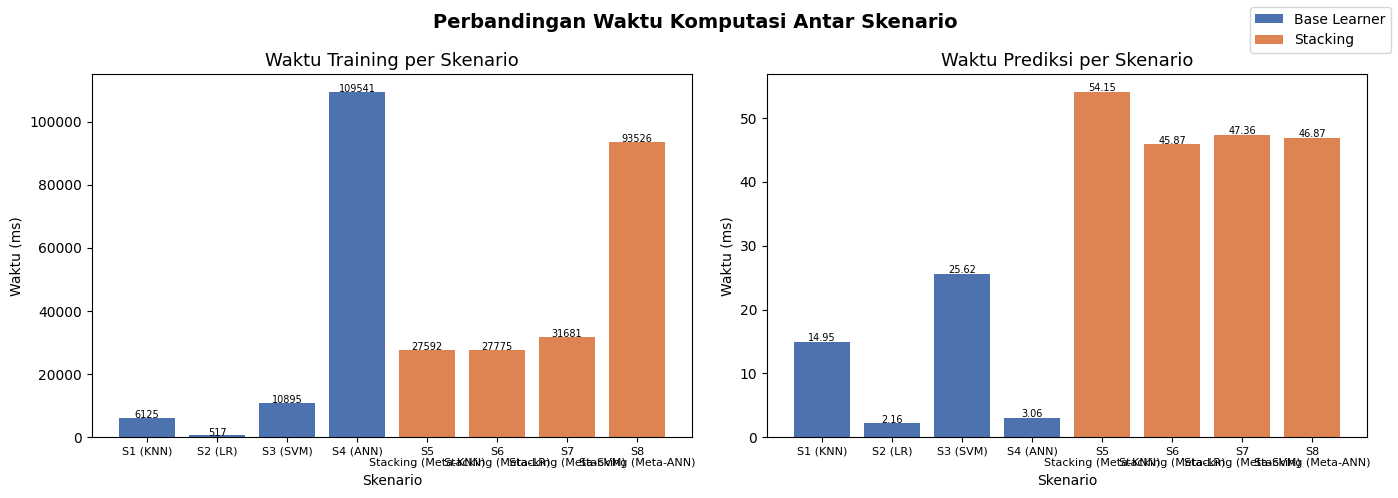

In [52]:
# Visualisasi perbandingan waktu komputasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

warna = [
    "#4C72B0", "#4C72B0", "#4C72B0", "#4C72B0",  # base learner — biru
    "#DD8452", "#DD8452", "#DD8452", "#DD8452",  # stacking — oranye
]
skenario_labels = [s.replace("Skenario ", "S").replace(" Stacking", "\nStacking") for s in df_waktu["Skenario"]]

# Waktu Training
axes[0].bar(skenario_labels, df_waktu["Waktu Training (ms)"], color=warna)
axes[0].set_title("Waktu Training per Skenario", fontsize=13)
axes[0].set_ylabel("Waktu (ms)")
axes[0].set_xlabel("Skenario")
axes[0].tick_params(axis="x", labelsize=8)
for i, v in enumerate(df_waktu["Waktu Training (ms)"]):
    axes[0].text(i, v + 0.5, f"{v:.0f}", ha="center", fontsize=7)

# Waktu Prediksi
axes[1].bar(skenario_labels, df_waktu["Waktu Prediksi (ms)"], color=warna)
axes[1].set_title("Waktu Prediksi per Skenario", fontsize=13)
axes[1].set_ylabel("Waktu (ms)")
axes[1].set_xlabel("Skenario")
axes[1].tick_params(axis="x", labelsize=8)
for i, v in enumerate(df_waktu["Waktu Prediksi (ms)"]):
    axes[1].text(i, v + 0.1, f"{v:.2f}", ha="center", fontsize=7)

# Legend manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#4C72B0", label="Base Learner"),
                   Patch(facecolor="#DD8452", label="Stacking")]
fig.legend(handles=legend_elements, loc="upper right", fontsize=10)

plt.suptitle("Perbandingan Waktu Komputasi Antar Skenario", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [53]:
# Ekspor tabel waktu komputasi ke Excel
df_waktu.to_excel("waktu_komputasi_skenario.xlsx", index=False)
print("Tabel waktu komputasi tersimpan: waktu_komputasi_skenario.xlsx")

Tabel waktu komputasi tersimpan: waktu_komputasi_skenario.xlsx


## Bedah Model

### KNN S1

In [54]:
import numpy as np
import pandas as pd
from IPython.display import display

# 1. Hitung jarak dan probabilitas untuk seluruh data testing
distances_all, indices_all = knn_final.kneighbors(X_test)
prob_all = knn_final.predict_proba(X_test)[:, 1]

# 2. Filter data secara ketat
valid_indices = []
for i in range(len(distances_all)):
    dists = distances_all[i]
    prob = prob_all[i]

    # Syarat 1: Probabilitas BUKAN 0.0 dan BUKAN 1.0 (Harus ada campuran kelas tetangga)
    if prob == 0.0 or prob == 1.0:
        continue

    # Syarat 2: Jarak pertama tidak boleh 0.0000
    if dists[0] == 0:
        continue

    # Syarat 3: Jarak harus bervariasi (minimal 4 jarak berbeda dari 5 tetangga)
    unique_dists = np.unique(dists)
    if len(unique_dists) >= 4:
        valid_indices.append(i)

valid_indices = np.array(valid_indices)

# 3. Ambil 5 sampel acak dari daftar yang sudah difilter
if len(valid_indices) < 5:
    print(f"Catatan: Hanya ditemukan {len(valid_indices)} data yang memenuhi syarat ketat ini.")
    sample_idx = valid_indices
else:
    np.random.seed(42) # Angka seed agar hasilnya tetap sama jika di-run ulang
    sample_idx = np.random.choice(valid_indices, 5, replace=False)

# 4. Ambil data sampel berdasarkan indeks yang terpilih
X_sample = X_test.values[sample_idx] if hasattr(X_test, 'values') else X_test[sample_idx]
y_sample_asli = y_test.values[sample_idx] if hasattr(y_test, 'values') else y_test[sample_idx]
index_sample = y_test.index[sample_idx] if hasattr(y_test, 'index') else sample_idx

# 5. Dapatkan jarak dan indeks 5 tetangga terdekat khusus
distances = distances_all[sample_idx]
indices = indices_all[sample_idx]

# 6. Dapatkan probabilitas (Kelas 0 dan 1) dan prediksi akhir
prob_library = knn_final.predict_proba(X_sample)
pred_library = knn_final.predict(X_sample)

# 7. Ambil label asli dari data training untuk mengetahui kelas tetangga
y_train_array = y_train_smote.values if hasattr(y_train_smote, 'values') else y_train_smote

# 8. Susun data menjadi DataFrame
data_tabel = []
for i in range(len(X_sample)):
    row_data = {
        # 'Urutan di Data Uji': sample_idx[i],
        # 'Index': index_sample[i]
    }

    # Memasukkan jarak dan kelas untuk masing-masing ke-5 tetangga
    for k in range(5):
        dist = distances[i][k]
        kelas_tetangga = y_train_array[indices[i][k]]
        row_data[f'Tetangga {k+1}'] = f"{dist:.4f} (K:{kelas_tetangga})"

    # Memasukkan hasil probabilitas Kelas 0, Kelas 1, dan Prediksi
    # row_data['Probabilitas Kelas 0'] = round(prob_library[i][0], 5)
    # row_data['Probabilitas Kelas 1'] = round(prob_library[i][1], 5)
    row_data['Prediksi Model'] = pred_library[i]
    row_data['Label Asli'] = y_sample_asli[i]

    data_tabel.append(row_data)

df_knn_sempurna = pd.DataFrame(data_tabel)

print("--- DETAIL JARAK TETANGGA (VARIAN JARAK & PROBABILITAS CAMPURAN) ---")
display(df_knn_sempurna)

--- DETAIL JARAK TETANGGA (VARIAN JARAK & PROBABILITAS CAMPURAN) ---


,Tetangga 1,Tetangga 2,Tetangga 3,Tetangga 4,Tetangga 5,Prediksi Model,Label Asli
0,0.3829 (K:0),0.4330 (K:1),0.4330 (K:1),0.4438 (K:0),0.4488 (K:0),0,0
1,0.3274 (K:1),0.3579 (K:1),0.3579 (K:1),0.3659 (K:0),0.3753 (K:0),1,0
2,0.7525 (K:1),0.7995 (K:1),0.8073 (K:1),0.8110 (K:0),0.8110 (K:0),1,1
3,0.4023 (K:0),0.4023 (K:0),0.4030 (K:1),0.4493 (K:1),0.5625 (K:1),1,1
4,0.3274 (K:1),0.3579 (K:1),0.3579 (K:1),0.3659 (K:0),0.3753 (K:0),1,0


### LR S2

In [55]:
import numpy as np
import pandas as pd
from IPython.display import display

# 1. Pastikan data testing berbentuk matriks angka
X_test_array = X_test.values if hasattr(X_test, 'values') else X_test

# 2. Ambil koefisien (w) dan intercept (b)
w = lr_final.coef_[0]
b = lr_final.intercept_[0]

# 3. KALKULASI MATEMATIS MANUAL
# Hitung kombinasi linear (z) = w*x + b
z_manual = np.dot(X_test_array, w) + b

# Hitung f(x) menggunakan rumus Sigmoid
fx_manual = 1 / (1 + np.exp(-z_manual))

# Probabilitas Kelas 1 dan Kelas 0
p_manual_1 = fx_manual
p_manual_0 = 1 - p_manual_1

# 4. KEPUTUSAN PREDIKSI (Berdasarkan teori ambang batas > 0.5)
# Jika fx_manual >= 0.5, maka hasilnya 1. Jika tidak, hasilnya 0.
prediksi_manual = (fx_manual >= 0.5).astype(int)

# 5. SUSUN TABEL MANUAL
df_manual = pd.DataFrame({

    'Hasil z': z_manual.round(5),
    'Hasil f(x)': fx_manual.round(5),
    'Prediksi Model': prediksi_manual,
    'Label Asli': y_test.values if hasattr(y_test, 'values') else y_test,
})

print("--- BUKTI PERHITUNGAN MATEMATIS MANUAL ---")
display(df_manual.head(5))

--- BUKTI PERHITUNGAN MATEMATIS MANUAL ---


,Hasil z,Hasil f(x),Prediksi Model,Label Asli
0,0.22926,0.55707,1,1
1,-0.23740,0.44093,0,0
2,0.40145,0.59903,1,1
3,0.08456,0.52113,1,1
4,0.16627,0.54147,1,1


### SVM S3

In [56]:
import numpy as np
import pandas as pd
from IPython.display import display

# 1. Pastikan data berformat array
X_test_array = X_test.values if hasattr(X_test, 'values') else X_test

# 2. Ekstrak parameter matematis dari model SVM RBF Anda
SVs = svm_final.support_vectors_       # Koordinat titik Support Vectors
dual_coefs = svm_final.dual_coef_[0]   # Koefisien dual (Alpha * y)
b = svm_final.intercept_[0]            # Nilai bias (konstanta)
gamma = svm_final._gamma            # Nilai gamma dari kernel RBF

# 3. KALKULASI MATEMATIS FUNGSI KEPUTUSAN UNTUK SELURUH DATA TESTING
fx_list = []
prediksi_list = []

for sample_x in X_test_array:
    # a. Hitung kuadrat jarak (Euclidean) ke semua Support Vectors
    sq_distances = np.sum((SVs - sample_x) ** 2, axis=1)

    # b. Fungsi Kernel RBF
    K = np.exp(-gamma * sq_distances)

    # c. Fungsi Keputusan f(x)
    fx = np.dot(dual_coefs, K) + b
    fx_list.append(fx)

    # d. Aturan Keputusan SVM (Threshold 0)
    prediksi = 1 if fx >= 0 else 0
    prediksi_list.append(prediksi)

# 4. SUSUN TABEL HASIL MATEMATIS
df_matematis = pd.DataFrame({
    'f(x)': np.round(fx_list, 5),
    'Prediksi Model': prediksi_list,
    'Label Asli': y_test.values if hasattr(y_test, 'values') else y_test,
})

print("--- HASIL PERHITUNGAN MATEMATIS FUNGSI KEPUTUSAN SVM ---")
display(df_matematis.head(5))

--- HASIL PERHITUNGAN MATEMATIS FUNGSI KEPUTUSAN SVM ---


,f(x),Prediksi Model,Label Asli
0,0.99985,1,1
1,-3.63750,0,0
2,1.58475,1,1
3,0.99924,1,1
4,11.50849,1,1


### ANN S4

In [ ]:

from IPython.display import display

# 1. Pastikan data berformat array
X_test_array = X_test.values if hasattr(X_test, 'values') else X_test

# 2. Ekstrak matriks bobot (W) dan bias (b) dari model ANN
W1, W2, W3 = ann_final.coefs_
b1, b2, b3 = ann_final.intercepts_

# 3. PROSES FORWARD PROPAGATION MANUAL
# --- Langkah 1: Input ke Hidden Layer 1 ---
# Z1 = (X * W1) + b1
Z1 = np.dot(X_test_array, W1) + b1
# Fungsi Aktivasi ReLU: max(0, Z)
A1 = np.maximum(0, Z1)

# --- Langkah 2: Hidden Layer 1 ke Hidden Layer 2 ---
# Z2 = (A1 * W2) + b2
Z2 = np.dot(A1, W2) + b2
# Fungsi Aktivasi ReLU
A2 = np.maximum(0, Z2)

# --- Langkah 3: Hidden Layer 2 ke Output Layer ---
# Z3 = (A2 * W3) + b3
Z3 = np.dot(A2, W3) + b3
# Karena matriks hasil ukurannya (N, 1), kita ratakan (flatten) jadi 1 dimensi
Z3 = Z3.flatten()

# Fungsi Aktivasi Output: Logistic (Sigmoid)
p_manual_1 = 1 / (1 + np.exp(-Z3))
p_manual_0 = 1 - p_manual_1



# 5. SUSUN TABEL KOMPARASI
df_ann_komparasi = pd.DataFrame({
    'Probabilitas Kelas 1 (Manual Forward Prop)': p_manual_1.round(6),
})


display(df_ann_komparasi.head(15))

,Index Asli,Probabilitas Kelas 1 (Manual Forward Prop),Probabilitas Kelas 1 (Library),Apakah Sama?
0,1860,0.208446,0.208446,✅ Ya
1,353,0.000519,0.000519,✅ Ya
2,1333,0.753009,0.753009,✅ Ya
3,905,0.596329,0.596329,✅ Ya
4,1289,0.916727,0.916727,✅ Ya
5,1273,0.734515,0.734515,✅ Ya
6,938,0.672728,0.672728,✅ Ya
7,1731,0.090463,0.090463,✅ Ya
8,65,0.391471,0.391471,✅ Ya
9,1323,0.832418,0.832418,✅ Ya


### META-KNN S5

In [58]:
import numpy as np
import pandas as pd
from IPython.display import display

# 1. Hitung jarak dan indeks untuk seluruh data meta-features uji
distances_all, indices_all = knn_meta_final.kneighbors(X_meta_uji)
pred_all = knn_meta_final.predict(X_meta_uji)
y_train_meta_array = y_meta_latih.values if hasattr(y_meta_latih, 'values') else y_meta_latih

# 2. Filter khusus: Cari data yang komposisi 13 tetangganya BERCAMPUR (Heterogen)
valid_indices = []
for i in range(len(distances_all)):
    inds = indices_all[i]
    kelas_tetangga = y_train_meta_array[inds]

    # Menghitung berapa banyak Kelas 0 dan Kelas 1 di antara 13 tetangga
    count_k0 = np.sum(kelas_tetangga == 0)
    count_k1 = np.sum(kelas_tetangga == 1)

    # Syarat Campuran: Minimal ada 3 tetangga dari kelas yang berbeda (tidak boleh 13-0 atau 12-1)
    if count_k0 >= 3 and count_k1 >= 3:
        # Syarat tambahan: Jarak tidak boleh nol (bukan duplikat)
        if distances_all[i][0] > 0:
            valid_indices.append(i)

valid_indices = np.array(valid_indices)

# 3. Ambil 5 sampel dari hasil filter
if len(valid_indices) < 5:
    print(f"Hanya ditemukan {len(valid_indices)} data dengan tetangga campuran. Mengambil semua yang ada.")
    sample_idx = valid_indices
else:
    np.random.seed(10) # Seed diubah agar mendapat variasi baru
    sample_idx = np.random.choice(valid_indices, 5, replace=False)

# 4. Susun data secara vertikal
y_sample_asli = y_meta_uji.values[sample_idx] if hasattr(y_meta_uji, 'values') else y_meta_uji[sample_idx]
data_tabel = {}

for i in range(len(sample_idx)):
    col_name = f"Data uji {i+1}"
    row_values = []

    dists = distances_all[sample_idx[i]]
    inds = indices_all[sample_idx[i]]

    for k in range(11):
        row_values.append(f"{dists[k]:.4f} (K:{y_train_meta_array[inds[k]]})")

    row_values.append(int(pred_all[sample_idx[i]]))
    row_values.append(int(y_sample_asli[i]))

    data_tabel[col_name] = row_values

indeks_baris = [f"Tetangga {i+1}" for i in range(11)] + ["PREDIKSI META", "LABEL ASLI"]
df_vertikal = pd.DataFrame(data_tabel, index=indeks_baris)

print("--- DETAIL 13 TETANGGA (KOMPOSISI CAMPURAN/HETEROGEN) ---")
display(df_vertikal)

--- DETAIL 13 TETANGGA (KOMPOSISI CAMPURAN/HETEROGEN) ---


,Data uji 1,Data uji 2,Data uji 3,Data uji 4,Data uji 5
Tetangga 1,0.3662 (K:0),0.1258 (K:1),0.2162 (K:0),0.1242 (K:0),0.5481 (K:1)
Tetangga 2,0.3662 (K:0),0.1435 (K:1),0.2275 (K:1),0.3569 (K:1),0.6134 (K:0)
Tetangga 3,0.6591 (K:1),0.1485 (K:0),0.3542 (K:1),0.3569 (K:1),0.6134 (K:0)
Tetangga 4,0.8461 (K:1),0.1485 (K:0),0.4169 (K:0),0.4547 (K:1),0.7457 (K:1)
Tetangga 5,0.9489 (K:1),0.1485 (K:0),0.4348 (K:0),0.6160 (K:1),0.9481 (K:1)
Tetangga 6,0.9686 (K:1),0.1513 (K:1),0.5134 (K:1),0.6880 (K:0),0.9803 (K:0)
Tetangga 7,1.0879 (K:0),0.1513 (K:1),0.5160 (K:1),0.6880 (K:0),1.0031 (K:1)
Tetangga 8,1.1038 (K:1),0.1764 (K:1),0.5180 (K:1),0.7578 (K:1),1.0437 (K:1)
Tetangga 9,1.1154 (K:0),0.2308 (K:1),0.5358 (K:1),0.8664 (K:0),1.0744 (K:1)
Tetangga 10,1.1310 (K:1),0.2395 (K:1),0.5560 (K:1),0.9266 (K:1),1.1602 (K:0)


### META-LR S6

In [59]:
import numpy as np
import pandas as pd
from IPython.display import display

# 1. Pastikan data testing berbentuk matriks angka
X_test_array = X_meta_uji.values if hasattr(X_meta_uji, 'values') else X_meta_uji

# 2. Ambil koefisien (w) dan intercept (b)
w = logreg_meta_final.coef_[0]
b = logreg_meta_final.intercept_[0]

# 3. KALKULASI MATEMATIS MANUAL
# Hitung kombinasi linear (z) = w*x + b
z_manual = np.dot(X_test_array, w) + b

# Hitung f(x) menggunakan rumus Sigmoid
fx_manual = 1 / (1 + np.exp(-z_manual))

# Probabilitas Kelas 1 dan Kelas 0
p_manual_1 = fx_manual
p_manual_0 = 1 - p_manual_1

# 4. KEPUTUSAN PREDIKSI (Berdasarkan teori ambang batas > 0.5)
# Jika fx_manual >= 0.5, maka hasilnya 1. Jika tidak, hasilnya 0.
prediksi_manual = (fx_manual >= 0.5).astype(int)

# 5. SUSUN TABEL MANUAL
df_manual = pd.DataFrame({
    'Hasil z': z_manual.round(5),
    'Hasil f(x)': fx_manual.round(5),
    'Prediksi Model': prediksi_manual,
    'Label Asli': y_test.values if hasattr(y_test, 'values') else y_test,
})

print("--- BUKTI PERHITUNGAN MATEMATIS MANUAL ---")
display(df_manual.head(5))

--- BUKTI PERHITUNGAN MATEMATIS MANUAL ---


,Hasil z,Hasil f(x),Prediksi Model,Label Asli
0,1.88851,0.86859,1,1
1,-3.98731,0.01821,0,0
2,2.71041,0.93764,1,1
3,2.34536,0.91256,1,1
4,3.08201,0.95614,1,1


### META-SVM S7

In [60]:
import numpy as np
import pandas as pd
from IPython.display import display

# 1. Pastikan data berformat array (menggunakan meta-features uji)
X_meta_uji_array = X_meta_uji.values if hasattr(X_meta_uji, 'values') else X_meta_uji

# 2. Ekstrak parameter matematis dari model SVM Linear
# meta_svm_final adalah nama variabel model SVM Stacking Anda
w = svm_meta_final.coef_[0]      # Koefisien bobot fitur meta
b = svm_meta_final.intercept_[0] # Nilai bias

# 3. KALKULASI MATEMATIS FUNGSI KEPUTUSAN (Linear: f(x) = Xw + b)
# Kita bisa menggunakan np.dot untuk perkalian matriks yang lebih cepat
fx_list = np.dot(X_meta_uji_array, w) + b

# 4. Aturan Keputusan (Threshold 0)
prediksi_list = [1 if fx >= 0 else 0 for fx in fx_list]

# 5. SUSUN TABEL HASIL MATEMATIS
df_matematis_svm = pd.DataFrame({
    'Nilai Jarak f(x)': np.round(fx_list, 5),
    'Prediksi Model': prediksi_list,
    'Label Asli': y_meta_uji.values if hasattr(y_meta_uji, 'values') else y_meta_uji
})

print("--- HASIL PERHITUNGAN MATEMATIS FUNGSI KEPUTUSAN META-SVM (LINEAR) ---")
display(df_matematis_svm.head(15))

--- HASIL PERHITUNGAN MATEMATIS FUNGSI KEPUTUSAN META-SVM (LINEAR) ---


,Nilai Jarak f(x),Prediksi Model,Label Asli
0,1.10976,1,1
1,-1.52094,0,0
2,1.26560,1,1
3,1.19200,1,1
4,1.35883,1,1
5,1.22350,1,1
6,1.21603,1,1
7,-1.51010,0,0
8,-1.42854,0,0
9,1.24062,1,1


### ANN-META S8

In [61]:
import pandas as pd
import numpy as np
from IPython.display import display

# 1. Menentukan jumlah data testing yang tersedia
n_total = len(X_meta_uji)

# 2. Mengambil 5 nomor urut posisi secara acak (misal: urutan ke-10, ke-50, dst)
np.random.seed(42) # Agar hasil acak tetap sama setiap kali dijalankan
random_pos = np.random.choice(n_total, 5, replace=False)

# 3. Mengambil data berdasarkan POSISI (iloc), bukan berdasarkan LABEL indeks
# Ini akan menghindari KeyError
X_meta_sample = X_meta_uji.iloc[random_pos]
y_sample_asli = y_meta_uji.iloc[random_pos]

# 4. Mendapatkan probabilitas dan prediksi dari model
prob_meta_ann = ann_meta_final.predict_proba(X_meta_sample)
pred_meta_ann = ann_meta_final.predict(X_meta_sample)

# 5. Menyusun ke dalam DataFrame untuk Tabel Skripsi
df_meta_ann_output = pd.DataFrame({
    'Hasil Output Layer': prob_meta_ann[:, 1].round(5),
    'Prediksi Model': pred_meta_ann,
    'Label Asli': y_sample_asli.values
})

# 6. Reset indeks agar tampil rapi 0-4
df_meta_ann_output = df_meta_ann_output.reset_index(drop=True)

print("--- 5 SAMPEL DATA TESTING (PROSES POSISI ILOC) ---")
display(df_meta_ann_output)

--- 5 SAMPEL DATA TESTING (PROSES POSISI ILOC) ---


,Hasil Output Layer,Prediksi Model,Label Asli
0,0.95335,1,1
1,0.02759,0,0
2,0.02127,0,0
3,0.96156,1,1
4,0.02297,0,0
